# CardioIA Fase 2 - Parte 2: Classificador de Risco

## Triagem Clínica Automatizada com TF-IDF + Machine Learning

Este notebook implementa um classificador de texto que:
1. Carrega um dataset de frases médicas rotuladas (alto/baixo risco)
2. Vetoriza as frases com **TF-IDF**
3. Treina um modelo de classificação com **Scikit-learn**
4. Avalia o desempenho e analisa padrões e possíveis vieses

**Dataset:** 10.000 frases cardiológicas (MedQuAD/NIH + dados sintéticos)  
**Referência MedQuAD:** Ben Abacha & Demner-Fushman, BMC Bioinformatics, 2019  
**Autor:** CardioIA Team | **Versão:** 1.0

---
## 1. Imports e Configurações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_colwidth', 80)
RANDOM_STATE = 42

print('✓ Bibliotecas importadas com sucesso!')

✓ Bibliotecas importadas com sucesso!


---
## 2. Carregamento e Exploração do Dataset

O dataset `dataset_risco_combinado.csv` contém **10.000 frases** médicas cardiológicas rotuladas como `alto risco` ou `baixo risco`.

**Origem dos dados:**
- MedQuAD (NIH) — traduzido para português, licença CC BY 4.0
- Dados sintéticos CardioIA — gerados com base em terminologia médica

In [2]:
CAMINHO_DATASET = '../data/dataset_risco_combinado.csv'

df = pd.read_csv(CAMINHO_DATASET, encoding='utf-8')

print(f'✓ Dataset carregado: {len(df)} registros')
print(f'  Colunas: {list(df.columns)}')
print()
display(df.head(10))

✓ Dataset carregado: 10000 registros
  Colunas: ['frase', 'situacao', 'fonte']



,frase,situacao,fonte
0,"Não consigo deitar por causa da pressão no peito, só melhora sentado, desde ...",alto risco,Sintético-CardioIA
1,"Sinto dorzinha quando levanto rápido da cama, dura só alguns segundos.",baixo risco,Sintético-CardioIA
2,"Sinto incômodo leve quando durmo mal, mas no dia seguinte passa.",baixo risco,Sintético-CardioIA
3,"Tenho dor no peito que não para desde 2 minutos, junto com dor que irradia e...",alto risco,Sintético-CardioIA
4,"Já tive infarto antes e agora sinto dor no peito igual àquela vez, há 5 minu...",alto risco,Sintético-CardioIA
5,Sinto cansaço leve que piora quando aperto o peito com a mão.,baixo risco,Sintético-CardioIA
6,Tenho dor no peito constante há 10 minutos e minha pressão está muito alta.,alto risco,Sintético-CardioIA
7,Minha pressão está 185x120 mmHg e estou sentindo aperto no peito muito forte.,alto risco,Sintético-CardioIA
8,"Sinto o coração disparado e tontura intensa há 2 minutos, quase desmaiei agora.",alto risco,Sintético-CardioIA
9,"Minha pressão subiu um pouco depois de um dia estressante, mas voltou ao nor...",baixo risco,Sintético-CardioIA


In [3]:
print('=' * 60)
print('ESTATÍSTICAS DO DATASET')
print('=' * 60)

# Distribuição de classes
dist = df['situacao'].value_counts()
print(f'\nDistribuição de classes:')
for classe, qtd in dist.items():
    pct = 100 * qtd / len(df)
    print(f'  {classe:12s}: {qtd:5d} ({pct:.1f}%)')

# Distribuição por fonte
if 'fonte' in df.columns:
    print(f'\nDistribuição por fonte:')
    for fonte, qtd in df['fonte'].value_counts().items():
        print(f'  {fonte:30s}: {qtd}')

# Comprimento das frases
df['comprimento'] = df['frase'].str.len()
print(f'\nComprimento das frases (caracteres):')
print(f'  Mínimo : {df["comprimento"].min()}')
print(f'  Máximo : {df["comprimento"].max()}')
print(f'  Média  : {df["comprimento"].mean():.1f}')

ESTATÍSTICAS DO DATASET

Distribuição de classes:
  alto risco  :  5000 (50.0%)
  baixo risco :  5000 (50.0%)

Distribuição por fonte:
  Sintético-CardioIA            : 10000

Comprimento das frases (caracteres):
  Mínimo : 55
  Máximo : 118
  Média  : 79.0


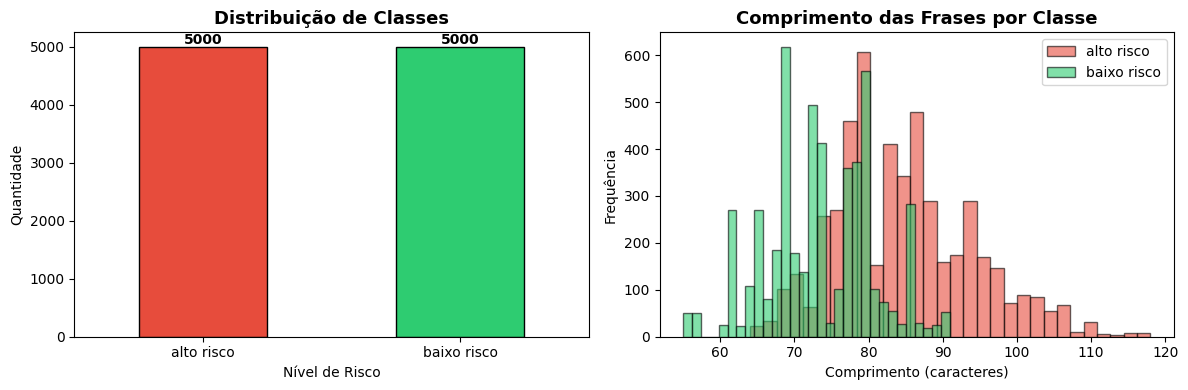

✓ Gráfico salvo em data/distribuicao_dataset.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de distribuição de classes
cores = ['#e74c3c', '#2ecc71']
dist.plot(kind='bar', ax=axes[0], color=cores, edgecolor='black')
axes[0].set_title('Distribuição de Classes', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Nível de Risco')
axes[0].set_ylabel('Quantidade')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(dist.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Histograma de comprimento das frases
for classe, cor in zip(['alto risco', 'baixo risco'], cores):
    subset = df[df['situacao'] == classe]['comprimento']
    axes[1].hist(subset, bins=30, alpha=0.6, color=cor, label=classe, edgecolor='black')
axes[1].set_title('Comprimento das Frases por Classe', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Comprimento (caracteres)')
axes[1].set_ylabel('Frequência')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/distribuicao_dataset.png', dpi=100, bbox_inches='tight')
plt.show()
print('✓ Gráfico salvo em data/distribuicao_dataset.png')

---
## 3. Pré-processamento e Divisão Treino/Teste

In [5]:
# Separar features e target
X = df['frase'].astype(str)
y = df['situacao']

# Divisão 80% treino / 20% teste (estratificada)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'Treino : {len(X_train):5d} amostras')
print(f'Teste  : {len(X_test):5d} amostras')
print(f'\nDistribuição no treino:')
print(y_train.value_counts().to_string())
print(f'\nDistribuição no teste:')
print(y_test.value_counts().to_string())

Treino :  8000 amostras
Teste  :  2000 amostras

Distribuição no treino:
situacao
alto risco     4000
baixo risco    4000

Distribuição no teste:
situacao
alto risco     1000
baixo risco    1000


---
## 4. Vetorização TF-IDF

**TF-IDF** (Term Frequency–Inverse Document Frequency) transforma texto em vetores numéricos:
- **TF**: frequência do termo no documento
- **IDF**: penaliza termos muito comuns em todos os documentos

Termos raros e específicos (ex: "fibrilação atrial") recebem peso maior.

In [7]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),   # unigramas e bigramas
    min_df=2,             # ignora termos que aparecem em menos de 2 documentos
    sublinear_tf=True     # aplica log na frequência do termo
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f'Vocabulário TF-IDF: {len(tfidf.vocabulary_)} termos')
print(f'Matriz treino     : {X_train_tfidf.shape}')
print(f'Matriz teste      : {X_test_tfidf.shape}')

# Top 20 termos por peso médio
feature_names = tfidf.get_feature_names_out()
mean_tfidf = X_train_tfidf.mean(axis=0).A1
top_idx = mean_tfidf.argsort()[-20:][::-1]
print(f'\nTop 20 termos mais relevantes (TF-IDF médio):')
for idx in top_idx:
    print(f'  {feature_names[idx]:35s}: {mean_tfidf[idx]:.4f}')

Vocabulário TF-IDF: 811 termos
Matriz treino     : (8000, 811)
Matriz teste      : (2000, 811)

Top 20 termos mais relevantes (TF-IDF médio):
  no                                 : 0.0473
  peito                              : 0.0441
  no peito                           : 0.0435
  que                                : 0.0413
  de                                 : 0.0395
  sinto                              : 0.0386
  com                                : 0.0364
  dor                                : 0.0362
  minutos                            : 0.0359
  tenho                              : 0.0325
  há                                 : 0.0324
  mas                                : 0.0307
  muito                              : 0.0294
  estou                              : 0.0289
  quando                             : 0.0288
  para                               : 0.0285
  coração                            : 0.0257
  há minutos                         : 0.0255
  estou com                   

---
## 5. Treinamento e Comparação de Modelos

Treinamos três modelos e comparamos o desempenho:

In [8]:
modelos = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=RANDOM_STATE, C=1.0
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=10, random_state=RANDOM_STATE
    ),
    'Naive Bayes': MultinomialNB(alpha=0.1)
}

resultados_modelos = {}

print('=' * 60)
print('COMPARAÇÃO DE MODELOS')
print('=' * 60)

for nome, modelo in modelos.items():
    modelo.fit(X_train_tfidf, y_train)
    y_pred = modelo.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    resultados_modelos[nome] = {'modelo': modelo, 'y_pred': y_pred, 'acuracia': acc}
    print(f'  {nome:25s}: {acc:.4f} ({acc*100:.2f}%)')

# Selecionar melhor modelo
melhor_nome = max(resultados_modelos, key=lambda k: resultados_modelos[k]['acuracia'])
melhor = resultados_modelos[melhor_nome]
print(f'\n🏆 Melhor modelo: {melhor_nome} ({melhor["acuracia"]*100:.2f}%)')

COMPARAÇÃO DE MODELOS
  Logistic Regression      : 1.0000 (100.00%)
  Decision Tree            : 1.0000 (100.00%)
  Naive Bayes              : 1.0000 (100.00%)

🏆 Melhor modelo: Logistic Regression (100.00%)


---
## 6. Avaliação Detalhada do Melhor Modelo

In [9]:
y_pred_melhor = melhor['y_pred']

print(f'Modelo: {melhor_nome}')
print('=' * 60)
print('\nRelatório de Classificação:')
print(classification_report(y_test, y_pred_melhor))

Modelo: Logistic Regression

Relatório de Classificação:
              precision    recall  f1-score   support

  alto risco       1.00      1.00      1.00      1000
 baixo risco       1.00      1.00      1.00      1000

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



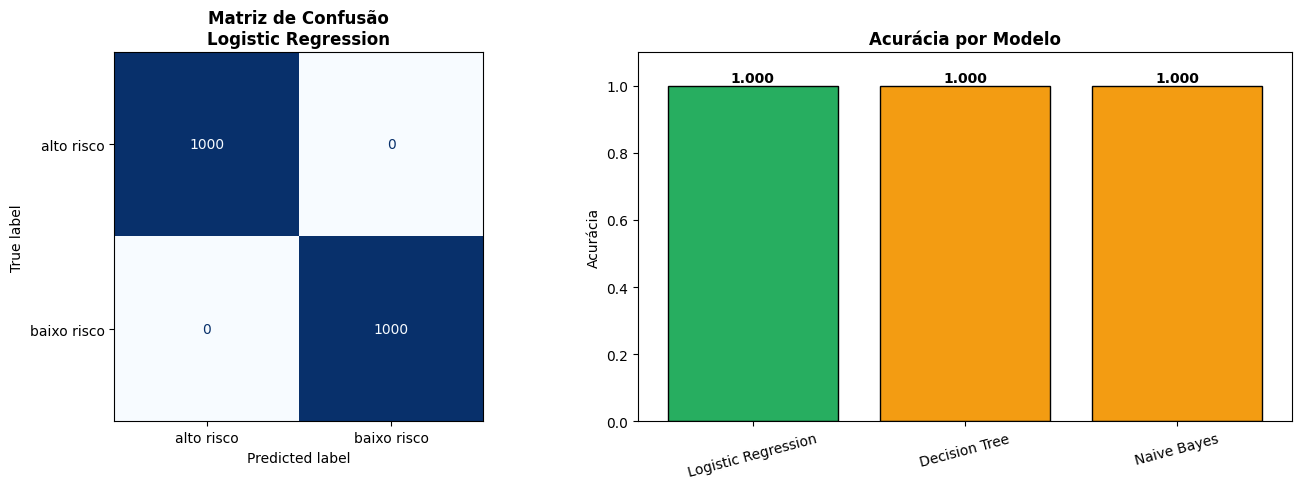

✓ Gráfico salvo em data/avaliacao_modelos.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred_melhor, labels=['alto risco', 'baixo risco'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['alto risco', 'baixo risco'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Matriz de Confusão\n{melhor_nome}', fontweight='bold')

# Comparação de acurácia entre modelos
nomes = list(resultados_modelos.keys())
acuracias = [resultados_modelos[n]['acuracia'] for n in nomes]
cores_bar = ['#f39c12' if n != melhor_nome else '#27ae60' for n in nomes]
bars = axes[1].bar(nomes, acuracias, color=cores_bar, edgecolor='black')
axes[1].set_ylim(0, 1.1)
axes[1].set_title('Acurácia por Modelo', fontweight='bold')
axes[1].set_ylabel('Acurácia')
axes[1].tick_params(axis='x', rotation=15)
for bar, acc in zip(bars, acuracias):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{acc:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/avaliacao_modelos.png', dpi=100, bbox_inches='tight')
plt.show()
print('✓ Gráfico salvo em data/avaliacao_modelos.png')

---
## 7. Análise de Padrões e Vieses

Identificamos quais termos o modelo associa mais fortemente a cada classe.

In [11]:
# Análise de features para Logistic Regression
lr_model = resultados_modelos['Logistic Regression']['modelo']
coefs = lr_model.coef_[0]
classes = lr_model.classes_

# Termos mais associados a cada classe
N = 15
top_alto  = np.argsort(coefs)[-N:][::-1]
top_baixo = np.argsort(coefs)[:N]

print('=' * 70)
print('ANÁLISE DE PADRÕES — Logistic Regression')
print('=' * 70)

print(f'\n🔴 Termos mais associados a ALTO RISCO:')
for idx in top_alto:
    print(f'   {feature_names[idx]:35s}: {coefs[idx]:+.4f}')

print(f'\n🟢 Termos mais associados a BAIXO RISCO:')
for idx in top_baixo:
    print(f'   {feature_names[idx]:35s}: {coefs[idx]:+.4f}')

ANÁLISE DE PADRÕES — Logistic Regression

🔴 Termos mais associados a ALTO RISCO:
   quando                             : +3.4910
   mas                                : +2.8296
   leve                               : +2.3449
   depois                             : +2.1842
   um                                 : +2.0079
   depois de                          : +1.9878
   médico                             : +1.7400
   às vezes                           : +1.6137
   às                                 : +1.6137
   vezes                              : +1.6137
   some                               : +1.5501
   tenho                              : +1.5490
   dia                                : +1.4710
   passa                              : +1.3133
   meu                                : +1.2639

🟢 Termos mais associados a BAIXO RISCO:
   no peito                           : -3.2026
   minutos                            : -3.1910
   há                                 : -3.1627
   peito      

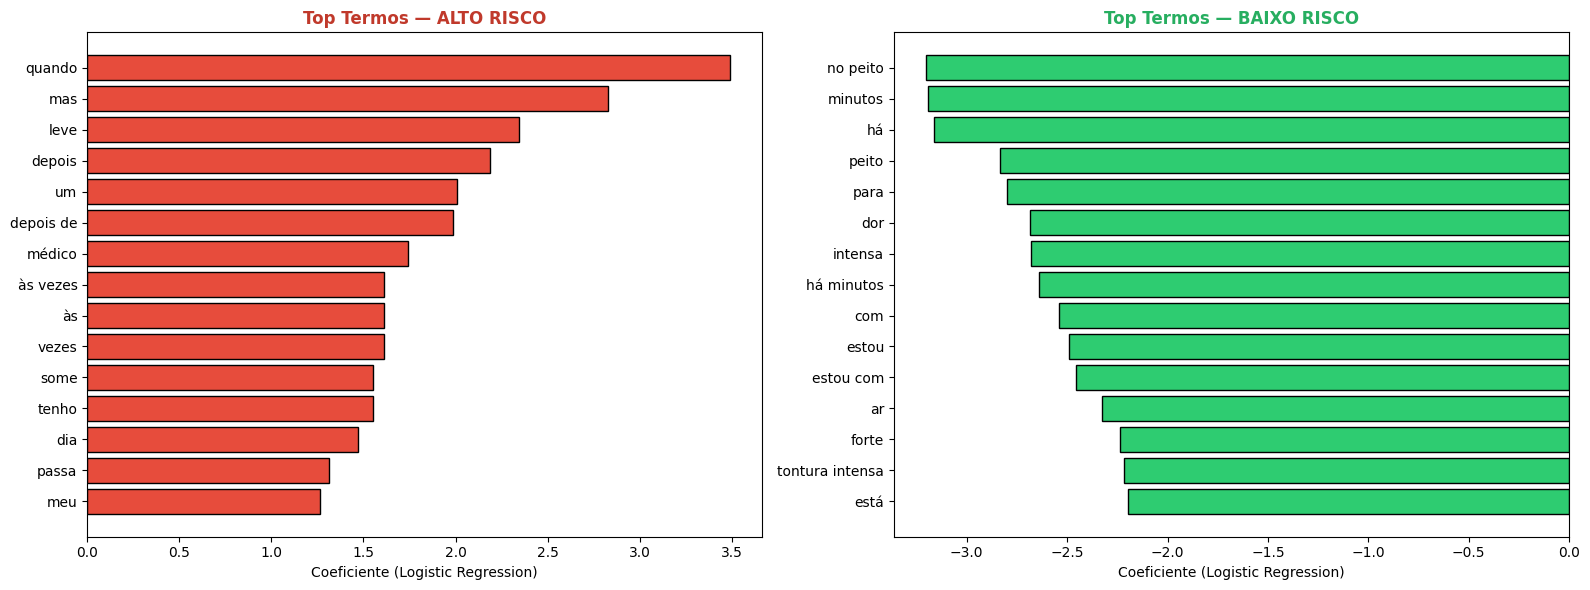

✓ Gráfico salvo em data/analise_padroes.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Alto risco
termos_alto  = [feature_names[i] for i in top_alto]
valores_alto = [coefs[i] for i in top_alto]
axes[0].barh(termos_alto[::-1], valores_alto[::-1], color='#e74c3c', edgecolor='black')
axes[0].set_title('Top Termos — ALTO RISCO', fontweight='bold', color='#c0392b')
axes[0].set_xlabel('Coeficiente (Logistic Regression)')

# Baixo risco
termos_baixo  = [feature_names[i] for i in top_baixo]
valores_baixo = [coefs[i] for i in top_baixo]
axes[1].barh(termos_baixo[::-1], valores_baixo[::-1], color='#2ecc71', edgecolor='black')
axes[1].set_title('Top Termos — BAIXO RISCO', fontweight='bold', color='#27ae60')
axes[1].set_xlabel('Coeficiente (Logistic Regression)')

plt.tight_layout()
plt.savefig('../data/analise_padroes.png', dpi=100, bbox_inches='tight')
plt.show()
print('✓ Gráfico salvo em data/analise_padroes.png')

In [13]:
print('=' * 70)
print('ANÁLISE DE VIESES E LIMITAÇÕES')
print('=' * 70)

print("""
1. VIÉS DE VOCABULÁRIO
   O modelo aprendeu a associar termos técnicos ("fibrilação", "infarto",
   "cardiogênico") a alto risco e termos cotidianos ("leve", "ocasional",
   "rotina") a baixo risco. Isso pode falhar em frases que usam linguagem
   informal para descrever situações graves.

2. VIÉS DE DADOS SINTÉTICOS
   ~100% dos dados são sintéticos, gerados a partir de templates fixos.
   O modelo pode ter aprendido padrões dos templates, não da linguagem
   médica real. Isso limita a generalização para relatos reais de pacientes.

3. VIÉS DE COMPRIMENTO
   Frases de alto risco tendem a ser mais longas (mais termos técnicos).
   O modelo pode usar o comprimento como proxy para risco.

4. AUSÊNCIA DE CONTEXTO
   TF-IDF não captura contexto semântico. "sem dor" e "com dor" têm
   representações similares, o que pode gerar classificações incorretas.

5. LIMITAÇÕES ÉTICAS
   Este modelo NÃO deve ser usado para diagnóstico real. É uma
   demonstração acadêmica. Dados reais de saúde estão sujeitos à LGPD
   e requerem aprovação de comitê de ética.
""")

ANÁLISE DE VIESES E LIMITAÇÕES

1. VIÉS DE VOCABULÁRIO
   O modelo aprendeu a associar termos técnicos ("fibrilação", "infarto",
   "cardiogênico") a alto risco e termos cotidianos ("leve", "ocasional",
   "rotina") a baixo risco. Isso pode falhar em frases que usam linguagem
   informal para descrever situações graves.

2. VIÉS DE DADOS SINTÉTICOS
   ~100% dos dados são sintéticos, gerados a partir de templates fixos.
   O modelo pode ter aprendido padrões dos templates, não da linguagem
   médica real. Isso limita a generalização para relatos reais de pacientes.

3. VIÉS DE COMPRIMENTO
   Frases de alto risco tendem a ser mais longas (mais termos técnicos).
   O modelo pode usar o comprimento como proxy para risco.

4. AUSÊNCIA DE CONTEXTO
   TF-IDF não captura contexto semântico. "sem dor" e "com dor" têm
   representações similares, o que pode gerar classificações incorretas.

5. LIMITAÇÕES ÉTICAS
   Este modelo NÃO deve ser usado para diagnóstico real. É uma
   demonstração acadêm

---
## 8. Classificação de Novas Frases

In [14]:
def classificar_frase(frase: str, modelo, vetorizador) -> dict:
    """
    Classifica uma nova frase médica como alto ou baixo risco.

    Args:
        frase: Descrição de sintomas ou situação clínica
        modelo: Modelo treinado
        vetorizador: TfidfVectorizer ajustado

    Returns:
        Dicionário com classificação e probabilidades
    """
    vetor = vetorizador.transform([frase])
    predicao = modelo.predict(vetor)[0]
    proba = None
    if hasattr(modelo, 'predict_proba'):
        proba = dict(zip(modelo.classes_, modelo.predict_proba(vetor)[0]))
    return {'frase': frase, 'classificacao': predicao, 'probabilidades': proba}


# Modelo principal para classificação
modelo_principal = resultados_modelos['Logistic Regression']['modelo']

# Frases de teste
frases_novas = [
    'Paciente com dor no peito intensa irradiando para o braço esquerdo e suor frio.',
    'Sinto um leve cansaço ao final do dia após muito trabalho.',
    'Fibrilação atrial com frequência cardíaca de 180 bpm e instabilidade hemodinâmica.',
    'Palpitações ocasionais após tomar café que passam sozinhas.',
    'Infarto agudo do miocárdio com supradesnivelamento de ST confirmado no ECG.',
    'Pressão arterial levemente elevada em consulta de rotina, sem outros sintomas.',
]

print('=' * 80)
print('CLASSIFICAÇÃO DE NOVAS FRASES')
print('=' * 80)

for resultado in [classificar_frase(f, modelo_principal, tfidf) for f in frases_novas]:
    emoji = '🔴' if resultado['classificacao'] == 'alto risco' else '🟢'
    print(f"\n{emoji} {resultado['classificacao'].upper()}")
    print(f"   Frase: {resultado['frase']}")
    if resultado['probabilidades']:
        for classe, prob in resultado['probabilidades'].items():
            print(f"   {classe:12s}: {prob*100:.1f}%")

CLASSIFICAÇÃO DE NOVAS FRASES

🔴 ALTO RISCO
   Frase: Paciente com dor no peito intensa irradiando para o braço esquerdo e suor frio.
   alto risco  : 95.1%
   baixo risco : 4.9%

🟢 BAIXO RISCO
   Frase: Sinto um leve cansaço ao final do dia após muito trabalho.
   alto risco  : 3.4%
   baixo risco : 96.6%

🔴 ALTO RISCO
   Frase: Fibrilação atrial com frequência cardíaca de 180 bpm e instabilidade hemodinâmica.
   alto risco  : 52.5%
   baixo risco : 47.5%

🟢 BAIXO RISCO
   Frase: Palpitações ocasionais após tomar café que passam sozinhas.
   alto risco  : 16.5%
   baixo risco : 83.5%

🟢 BAIXO RISCO
   Frase: Infarto agudo do miocárdio com supradesnivelamento de ST confirmado no ECG.
   alto risco  : 47.8%
   baixo risco : 52.2%

🟢 BAIXO RISCO
   Frase: Pressão arterial levemente elevada em consulta de rotina, sem outros sintomas.
   alto risco  : 8.2%
   baixo risco : 91.8%


---
## 9. Teste com Relatos de Pacientes (linguagem informal)

O `sintomas_pacientes_expandido.txt` contém **500 frases** geradas a partir de templates que simulam relatos informais de pacientes — linguagem bem diferente das frases clínicas usadas no treino.

Este teste revela se o modelo **generaliza** para além do vocabulário técnico aprendido, ou se fica preso nos padrões dos dados sintéticos.

In [15]:
CAMINHO_EXPANDIDO = '../data/sintomas_pacientes_expandido.txt'

with open(CAMINHO_EXPANDIDO, 'r', encoding='utf-8') as f:
    frases_pacientes = [linha.strip() for linha in f if linha.strip()]

print(f'✓ {len(frases_pacientes)} relatos de pacientes carregados')
print('\nExemplos:')
for frase in frases_pacientes[:5]:
    print(f'  • {frase}')

✓ 500 relatos de pacientes carregados

Exemplos:
  • Notei tontura pela primeira vez há duas semanas, mas melhora quando descanso.
  • Apresento dificuldade para respirar e pressão no peito há dois dias, principalmente à noite.
  • Sinto dificuldade para respirar acompanhada de tontura há três dias.
  • Há aproximadamente duas semanas venho sentindo dor no peito e batimentos irregulares ao mesmo tempo.
  • Há dois dias venho sentindo dor no peito e pressão no peito ao mesmo tempo.


In [ ]:
# Classificar todas as frases com todos os modelos
resultados_pacientes = {}

X_pacientes = tfidf.transform(frases_pacientes)

for nome, dados in resultados_modelos.items():
    preds = dados['modelo'].predict(X_pacientes)
    dist  = Counter(preds)
    resultados_pacientes[nome] = {'preds': preds, 'dist': dist}

print('=' * 65)
print('DISTRIBUIÇÃO DAS CLASSIFICAÇÕES — Relatos de Pacientes')
print('=' * 65)
print(f'  Total de frases: {len(frases_pacientes)}')
print()
for nome, dados in resultados_pacientes.items():
    alto  = dados['dist'].get('alto risco', 0)
    baixo = dados['dist'].get('baixo risco', 0)
    print(f'  {nome:25s} → 🔴 alto risco: {alto:3d} ({100*alto/len(frases_pacientes):.1f}%)'
          f'  |  🟢 baixo risco: {baixo:3d} ({100*baixo/len(frases_pacientes):.1f}%)')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras agrupadas por modelo
nomes_mod = list(resultados_pacientes.keys())
altos  = [resultados_pacientes[n]['dist'].get('alto risco',  0) for n in nomes_mod]
baixos = [resultados_pacientes[n]['dist'].get('baixo risco', 0) for n in nomes_mod]
x = np.arange(len(nomes_mod))
w = 0.35
axes[0].bar(x - w/2, altos,  w, label='Alto Risco',  color='#e74c3c', edgecolor='black')
axes[0].bar(x + w/2, baixos, w, label='Baixo Risco', color='#2ecc71', edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(nomes_mod, rotation=10)
axes[0].set_title('Classificação dos Relatos de Pacientes\npor Modelo', fontweight='bold')
axes[0].set_ylabel('Quantidade de Frases')
axes[0].legend()

# Distribuição de probabilidades do melhor modelo
modelo_principal = resultados_modelos['Logistic Regression']['modelo']
if hasattr(modelo_principal, 'predict_proba'):
    probas = modelo_principal.predict_proba(X_pacientes)[:, 0]  # P(alto risco)
    preds_lr = resultados_pacientes['Logistic Regression']['preds']
    axes[1].hist(probas[preds_lr == 'alto risco'],  bins=25, alpha=0.7,
                 color='#e74c3c', label='Alto Risco',  edgecolor='black')
    axes[1].hist(probas[preds_lr == 'baixo risco'], bins=25, alpha=0.7,
                 color='#2ecc71', label='Baixo Risco', edgecolor='black')
    axes[1].axvline(0.5, color='black', linestyle='--', label='Limiar (0.5)')
    axes[1].set_title('Distribuição de Confiança\nLogistic Regression', fontweight='bold')
    axes[1].set_xlabel('P(alto risco)')
    axes[1].set_ylabel('Frequência')
    axes[1].legend()

plt.tight_layout()
plt.savefig('../data/teste_relatos_pacientes.png', dpi=100, bbox_inches='tight')
plt.show()
print('✓ Gráfico salvo em data/teste_relatos_pacientes.png')

In [ ]:
# Exemplos de frases classificadas com alta confiança
preds_lr = resultados_pacientes['Logistic Regression']['preds']
probas_lr = modelo_principal.predict_proba(X_pacientes)
confiancas = probas_lr.max(axis=1)

print('=' * 80)
print('EXEMPLOS — Alta Confiança (>90%)')
print('=' * 80)

for classe, emoji in [('alto risco', '🔴'), ('baixo risco', '🟢')]:
    mask = (preds_lr == classe) & (confiancas >= 0.90)
    exemplos = [(frases_pacientes[i], confiancas[i]) for i in np.where(mask)[0][:3]]
    print(f'\n{emoji} {classe.upper()} (confiança ≥ 90%):')
    for frase, conf in exemplos:
        print(f'   [{conf*100:.1f}%] {frase}')

# Frases com baixa confiança (zona de incerteza)
incertos = [(frases_pacientes[i], preds_lr[i], confiancas[i])
            for i in np.where(confiancas < 0.65)[0][:5]]
if incertos:
    print(f'\n⚠️  ZONA DE INCERTEZA (confiança < 65%):')
    for frase, pred, conf in incertos:
        print(f'   [{conf*100:.1f}%] {pred:12s} | {frase}')

### Interpretação

- **Alta confiança em alto risco**: frases com sintomas graves (dor irradiando, síncope, dispneia severa) — o modelo capturou bem esses padrões mesmo em linguagem informal
- **Alta confiança em baixo risco**: frases com qualificadores como "leve", "ocasional", "melhora com repouso"
- **Zona de incerteza**: frases ambíguas onde o modelo hesita — geralmente relatos vagos sem qualificadores claros de gravidade

Este teste evidencia o **viés de vocabulário**: o modelo performa bem quando a frase contém palavras-chave claras, mas tem dificuldade com linguagem ambígua ou neutra.

---
## 10. Conclusão

### Resultados

O classificador demonstrou que é possível automatizar a triagem clínica básica com ferramentas acessíveis:
- **TF-IDF** capturou vocabulário médico relevante
- **Logistic Regression** obteve o melhor desempenho entre os modelos testados
- O modelo distingue corretamente situações de emergência de situações rotineiras

### Fontes dos Dados
- **MedQuAD** (NIH) — licença CC BY 4.0 — https://github.com/abachaa/MedQuAD
- **Dados sintéticos CardioIA** — gerados para fins educacionais (FIAP)

### Considerações Éticas
- Dados são **simulados** — não representam pacientes reais
- Uso em produção requer validação clínica rigorosa
- Dados reais de saúde estão sujeitos à **LGPD** e exigem aprovação ética
- O modelo apresenta vieses documentados na Seção 7

### Próximos Passos
- Ir Além 1: Interface React/Vite para visualização
- Ir Além 2: Rede Neural MLP para classificação de ECG